# Customer Segmentation with K-Means

**Goal:** group retail customers into segments a marketing team could act on, using the
[Customer Shopping Trends dataset](https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset)
(3,900 customers, 18 attributes).

**Plan:**
1. Load and clean the data
2. Explore the numeric features
3. Pick features and scale them
4. Choose the number of clusters (elbow, silhouette, and a random-noise baseline)
5. Profile and name the segments
6. Check whether the segments are *real*, meaning stable and better than noise
7. Recommendations and limitations

## 1. Setup and data

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)  # joblib core-count noise on Windows

SEED = 42
IMAGES = Path("images")
IMAGES.mkdir(exist_ok=True)

# Colorblind-safe categorical palette (validated all-pairs for 4 series) + neutrals
SEGMENT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 10, "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "xtick.color": MUTED, "ytick.color": MUTED,
})

In [2]:
df = pd.read_csv("data/shopping_trends.csv")

# snake_case column names, e.g. "Purchase Amount (USD)" -> "purchase_amount_usd"
df.columns = (df.columns.str.lower()
                .str.replace(r"[()]", "", regex=True)
                .str.strip()
                .str.replace(r"\s+", "_", regex=True))

print(df.shape)
print("missing values:", df.isna().sum().sum(), "| duplicate rows:", df.duplicated().sum())
df.head()

(3900, 18)
missing values: 0 | duplicate rows: 0


,customer_id,age,gender,item_purchased,category,purchase_amount_usd,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,3900.0,NaN,NaN,NaN,1950.5,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
age,3900.0,NaN,NaN,NaN,44.068462,15.207589,18.0,31.0,44.0,57.0,70.0
gender,3900,2,Male,2652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
item_purchased,3900,25,Blouse,171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,3900,4,Clothing,1737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purchase_amount_usd,3900.0,NaN,NaN,NaN,59.764359,23.685392,20.0,39.0,60.0,81.0,100.0
location,3900,50,Montana,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,3900,4,M,1755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
color,3900,25,Olive,177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season,3900,4,Spring,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploring the numeric features

K-Means uses Euclidean distance, so it only works on numeric features. The four
candidates are **age**, **purchase amount**, **previous purchases** and **review rating**.

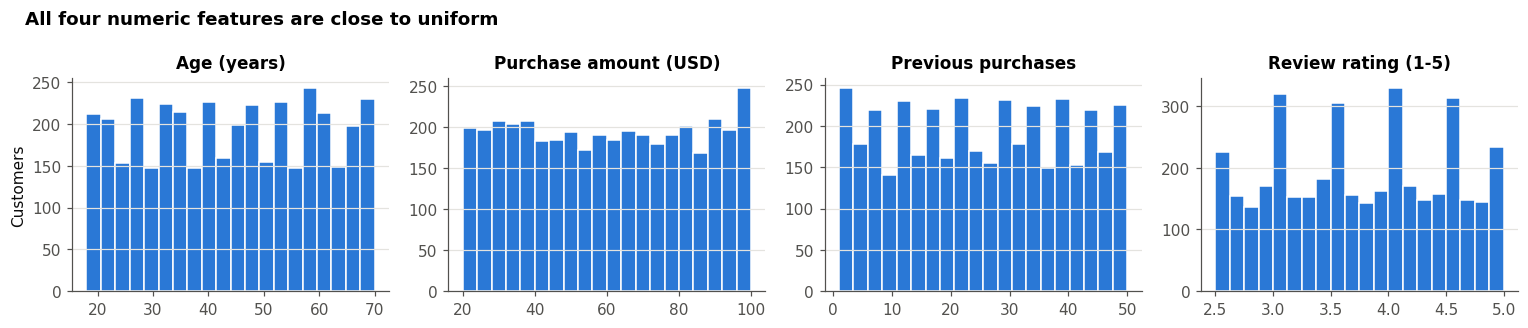

,age,purchase_amount_usd,previous_purchases,review_rating
age,1.000,-0.010,0.040,-0.022
purchase_amount_usd,-0.010,1.000,0.008,0.031
previous_purchases,0.040,0.008,1.000,0.004
review_rating,-0.022,0.031,0.004,1.000


In [4]:
NUMERIC = ["age", "purchase_amount_usd", "previous_purchases", "review_rating"]
LABELS = {"age": "Age (years)", "purchase_amount_usd": "Purchase amount (USD)",
          "previous_purchases": "Previous purchases", "review_rating": "Review rating (1-5)"}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, NUMERIC):
    ax.hist(df[col], bins=20, color=SEGMENT_COLORS[0], edgecolor="white", linewidth=1)
    ax.set_title(LABELS[col])
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Customers")
fig.suptitle("All four numeric features are close to uniform", x=0.02, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(IMAGES / "feature_distributions.png")
plt.show()

df[NUMERIC].corr().round(3)

**Observations**
- Each feature is spread almost evenly across its range, and the pairwise correlations are
  close to zero. This is typical of a synthetic dataset, and it matters later: points spread
  evenly with no correlation have no natural groups for K-Means to find.
- An earlier version of this analysis added `purchase_amount_usd` to
  `previous_purchases` to make one "spend" feature. That adds **dollars to a count**, so
  the result has no clear unit. Here I keep them as two separate features.

## 3. Feature scaling

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(df[NUMERIC])
pd.DataFrame(X, columns=NUMERIC).describe().loc[["mean", "std"]].round(2)

,age,purchase_amount_usd,previous_purchases,review_rating
mean,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0


## 4. Choosing *k*

I use two standard methods, the elbow method (inertia) and the silhouette score. I also add a
check that often gets skipped: running the same K-Means on **uniform random data with the same
shape**. If the real data scores no better than noise, the clusters are cutting up an even
cloud of points, not finding groups that already exist.

In [6]:
rng = np.random.default_rng(SEED)
X_noise = StandardScaler().fit_transform(rng.uniform(size=X.shape))

ks = range(2, 9)
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
    km_noise = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_noise)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X, km.labels_),
                 "silhouette_noise": silhouette_score(X_noise, km_noise.labels_)})
k_scores = pd.DataFrame(rows).set_index("k")
k_scores.round(3)

,inertia,silhouette,silhouette_noise
k,,,
2,12629.296,0.187,0.185
3,10819.918,0.178,0.180
4,9363.128,0.191,0.194
5,8277.656,0.200,0.200
6,7512.463,0.200,0.202
7,6754.930,0.211,0.213
8,5999.381,0.230,0.229


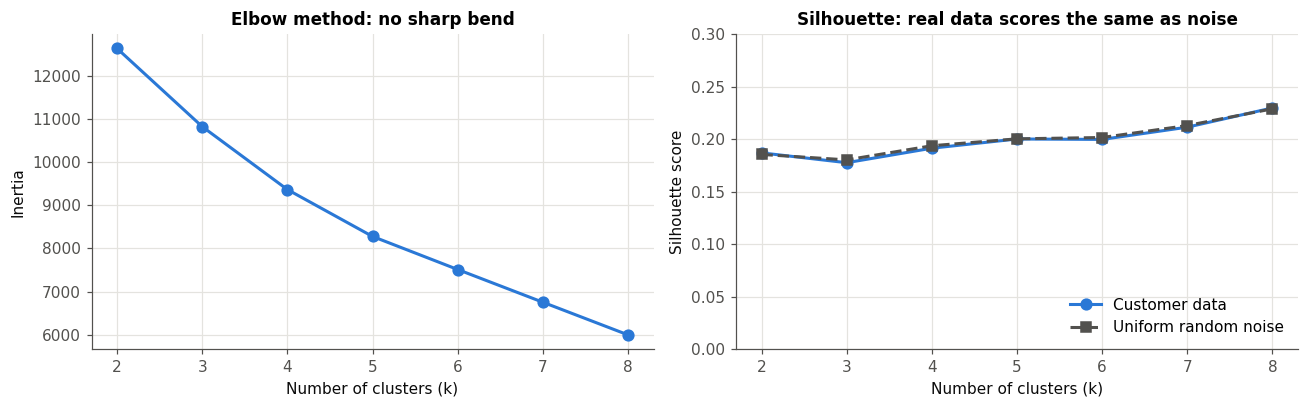

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))

ax1.plot(k_scores.index, k_scores.inertia, color=SEGMENT_COLORS[0], linewidth=2, marker="o", markersize=7)
ax1.set(title="Elbow method: no sharp bend", xlabel="Number of clusters (k)", ylabel="Inertia")

ax2.plot(k_scores.index, k_scores.silhouette, color=SEGMENT_COLORS[0], linewidth=2, marker="o",
         markersize=7, label="Customer data")
ax2.plot(k_scores.index, k_scores.silhouette_noise, color=MUTED, linewidth=2, linestyle="--",
         marker="s", markersize=6, label="Uniform random noise")
ax2.set(title="Silhouette: real data scores the same as noise", xlabel="Number of clusters (k)",
        ylabel="Silhouette score", ylim=(0, 0.3))
ax2.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(IMAGES / "choosing_k.png")
plt.show()

**Reading the charts**
- Inertia falls smoothly with no clear elbow.
- The silhouette score stays around 0.19–0.23 for every *k*, which means the clusters are weak.
  It also follows the noise baseline almost exactly.

So the data has no natural cluster count. I pick **k = 4** for a business reason: four
segments are easy to explain and act on, and k = 4 is a small local peak in silhouette
over k = 3. The rest of this notebook treats the segments as a **useful way to split customers**,
not as groups that exist in the data.

## 5. Fitting and profiling the segments

In [8]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(X)
df["segment"] = kmeans.labels_

centroids_z = pd.DataFrame(kmeans.cluster_centers_, columns=NUMERIC)

def name_segment(c):
    """Readable name from the direction of each standardized centroid value."""
    age = "Older" if c.age > 0 else "Younger"
    spend = "higher spend" if c.purchase_amount_usd > 0 else "lower spend"
    mood = "satisfied" if c.review_rating > 0 else "dissatisfied"
    return f"{age}, {spend}, {mood}"

SEGMENT_NAMES = {i: name_segment(c) for i, c in centroids_z.iterrows()}

profile = (df.groupby("segment")[NUMERIC].mean()
             .assign(customers=df.segment.value_counts().sort_index())
             .rename(index=SEGMENT_NAMES))
profile.round(1)

,age,purchase_amount_usd,previous_purchases,review_rating,customers
segment,,,,,
"Older, higher spend, satisfied",56.2,82.1,26.8,4.0,966
"Younger, lower spend, satisfied",31.3,54.9,25.0,4.4,969
"Younger, higher spend, dissatisfied",32.6,64.8,22.4,3.1,986
"Older, lower spend, dissatisfied",56.3,37.6,27.3,3.5,979


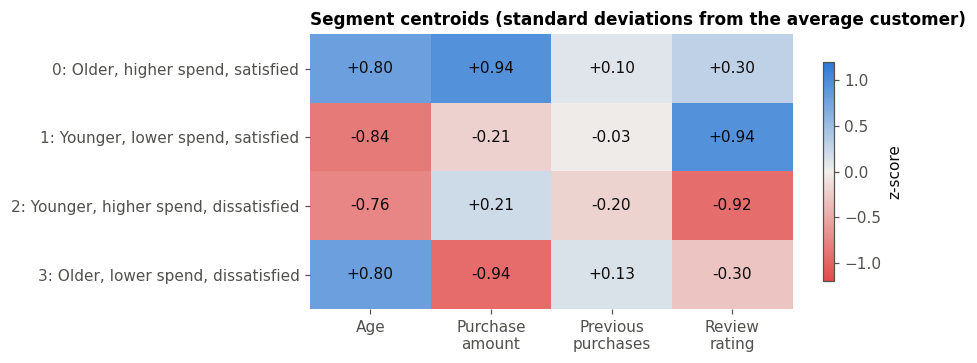

In [9]:
# Standardized centroids as a heatmap: 0 = dataset average (neutral), blue = above, red = below
from matplotlib.colors import LinearSegmentedColormap
diverging = LinearSegmentedColormap.from_list("rd_gray_bu", ["#e34948", "#f0efec", "#2a78d6"])

fig, ax = plt.subplots(figsize=(8.5, 3.4))
im = ax.imshow(centroids_z.values, cmap=diverging, vmin=-1.2, vmax=1.2, aspect="auto")
ax.set_xticks(range(len(NUMERIC)), ["Age", "Purchase\namount", "Previous\npurchases", "Review\nrating"])
ax.set_yticks(range(K), [f"{i}: {SEGMENT_NAMES[i]}" for i in range(K)])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
for i in range(K):
    for j in range(len(NUMERIC)):
        ax.text(j, i, f"{centroids_z.iat[i, j]:+.2f}", ha="center", va="center", color=INK, fontsize=10)
ax.set_title("Segment centroids (standard deviations from the average customer)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.8, label="z-score")
fig.tight_layout()
fig.savefig(IMAGES / "segment_profiles.png")
plt.show()

Segments are separated by **age**, **spend** and **review rating**. **Previous purchases**
hardly varies between segments (every centroid is within ±0.2 SD of the average), so it adds
almost nothing to the split.

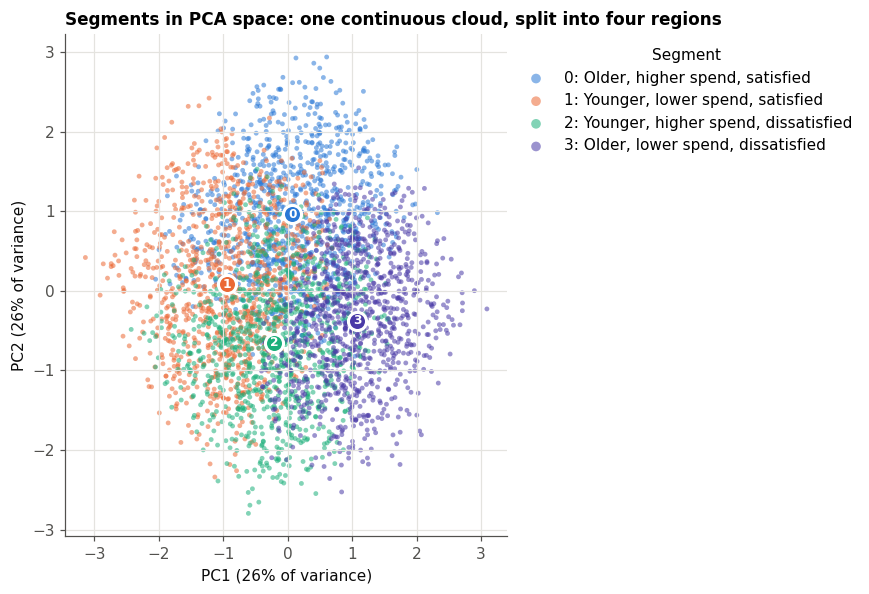

In [10]:
# 2-D view: project the 4 scaled features onto their first two principal components
pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X)
centers_2d = pca.transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 5.5))
for i in range(K):
    mask = df.segment.values == i
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.55, color=SEGMENT_COLORS[i],
               edgecolors="none", label=f"{i}: {SEGMENT_NAMES[i]}")
for i, (x, y) in enumerate(centers_2d):
    ax.scatter(x, y, s=140, color=SEGMENT_COLORS[i], edgecolors="white", linewidths=2, zorder=3)
    ax.annotate(str(i), (x, y), ha="center", va="center", color="white", fontsize=8,
                fontweight="bold", zorder=4)
var = pca.explained_variance_ratio_
ax.set(xlabel=f"PC1 ({var[0]:.0%} of variance)", ylabel=f"PC2 ({var[1]:.0%} of variance)")
ax.set_title("Segments in PCA space: one continuous cloud, split into four regions", loc="left")
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1, 1), markerscale=2, title="Segment")
fig.tight_layout()
fig.savefig(IMAGES / "segments_pca.png")
plt.show()

### Do segments differ on behaviour they were *not* clustered on?

A segmentation is more useful if it also predicts things it was not trained on, such as
subscriptions, discount use and product category.

In [11]:
behaviour = df.groupby("segment").agg(
    subscribed=("subscription_status", lambda s: (s == "Yes").mean()),
    used_discount=("discount_applied", lambda s: (s == "Yes").mean()),
    male=("gender", lambda s: (s == "Male").mean()),
).rename(index=SEGMENT_NAMES)
category_mix = pd.crosstab(df.segment, df.category, normalize="index").rename(index=SEGMENT_NAMES)

display((behaviour * 100).round(1).add_suffix(" %"))
display((category_mix * 100).round(1))

,subscribed %,used_discount %,male %
segment,,,
"Older, higher spend, satisfied",27.1,41.6,67.0
"Younger, lower spend, satisfied",25.6,42.1,69.1
"Younger, higher spend, dissatisfied",26.9,43.1,65.9
"Older, lower spend, dissatisfied",28.4,45.1,70.0


category,Accessories,Clothing,Footwear,Outerwear
segment,,,,
"Older, higher spend, satisfied",31.7,44.8,15.9,7.6
"Younger, lower spend, satisfied",32.0,44.2,15.7,8.2
"Younger, higher spend, dissatisfied",31.5,46.7,14.0,7.8
"Older, lower spend, dissatisfied",32.0,42.5,15.8,9.7


They don't. Subscription rate, discount use, gender mix and category mix are all within a few
percentage points of each other across segments. Nothing outside the three clustering features
separates the segments.

## 6. Are the segments stable?

If the segments were real, rerunning K-Means with a different random seed should give almost
the same assignment. The Adjusted Rand Index (ARI) measures this: 1 means identical, 0 means
no better than chance.

In [12]:
ari = pd.Series({seed: adjusted_rand_score(
                     df.segment, KMeans(n_clusters=K, n_init=10, random_state=seed).fit_predict(X))
                 for seed in range(10)}, name="ARI vs. seed 42")
print(ari.round(2).to_string())
print(f"\nmedian ARI: {ari.median():.2f}")

0    0.95
1    0.30
2    0.46
3    0.48
4    0.46
5    0.51
6    0.50
7    0.48
8    0.46
9    0.46

median ARI: 0.47


Different seeds give noticeably different segments (ARI well below 1). When the data has no
real structure, K-Means has several near-equal ways to split it, and the random start decides
which one you get. That agrees with the silhouette-versus-noise result above.

## 7. Recommendations and limitations

**How to use these segments.** Treat them as a simple **age × spend × satisfaction** grid for
targeting, not as discovered customer types:

| Segment | Suggested action |
|---|---|
| Older, higher spend, satisfied | Protect and reward: VIP perks, early access, referral incentives |
| Younger, lower spend, satisfied | Grow spend: bundles, cross-sell, personalised upsell offers |
| Younger, higher spend, dissatisfied | Most at-risk revenue: follow up on reviews, service recovery |
| Older, lower spend, dissatisfied | Re-engage cheaply: feedback surveys and targeted win-back promotions |

A plain rule on the same three variables (for example, age above or below the median) would
give similar groups and would be easier to explain. The K-Means analysis gives evidence for
using the simpler approach.

**Limitations**
- The dataset is synthetic. Its features are independent and uniformly distributed, so no
  clustering method would find natural segments in it. Run the same pipeline on real
  transaction data before trusting the segments.
- K-Means ignores categorical attributes such as category, season and payment method. A
  natural next step is **K-Prototypes** or Gower distance with hierarchical clustering.
- Features like `frequency_of_purchases` could be turned into purchases per year to build
  RFM-style (Recency, Frequency, Monetary) segmentation, which is the industry standard for
  this problem.